# e14 scaling campaign — accuracy improvements (v2 → v3, GT arm vs edges arm)

**Date:** 2026-08-10 · **wandb tag:** `e14_scaling` · **model:** `google/gemma-4-31B-it`, LoRA, lr 2.5e-4

The e14 campaign scaled nav-planning training off the old p152 suite and onto freshly generated
`n=60` graph corpora, to find out whether the **learned graph channel** (GT navigator Psi injected
through the graph channel) survives at realistic graph sizes — and how it compares to the trivial
bracket of just **writing the edge list into the prompt text**.

Three things moved over the campaign:

1. **v2 corpora (`n_{30,60}_vllm_v2`)** — clean rename-map populate contract, 26 train + 7 test
   graphs, 10 tasks/graph. Three arms per size: *floor* (node names, no connectivity anywhere),
   *edges-in-prompt*, and the *GT graph channel*. Result: the channel is a large real gain over the
   floor at both sizes, but text edges beat it at both, and the gap explodes with scale
   (n30 1.4×, n60 **8.2×**).
2. **v3 corpus (`n_60_vllm_v3`, widened)** — the data lever. 52 new train graphs (seeds 201–252,
   topologically disjoint from the frozen test set) ≈ 2× the training conversations, plus **2 extra
   long-hop Navigability tasks per graph** (12 tasks/graph, hop length sampled uniform over
   [3, diameter]). The 7 v2 test graphs were carried over frozen, so their original 10 tasks form a
   **legacy-10 subset** that compares directly against v2.
3. **Epoch extension** — the v3 GT arm was still climbing at the 3-epoch cutoff, so the identical
   recipe was rerun with `EPOCHS=6` to find that arm's actual ceiling.

Sources (the docs win on any conflict with this notebook):
`docs/2026-08-07 e14_scaling_v2_results.md`, `docs/2026-08-08 e14_scaling_v3_n60_widened_corpus.md`.

## Summary table

One row per training run. Accuracies are **in-training eval** (the `EvalCallback` path) unless the
column says reload; never mix the two paths inside one comparison.

In [1]:
# All numbers hardcoded from the campaign docs (do NOT re-derive or parse at runtime):
#   docs/2026-08-07 e14_scaling_v2_results.md            -> v2 rows (section 2 headline table)
#   docs/2026-08-08 e14_scaling_v3_n60_widened_corpus.md -> v3 rows (Results + 6-epoch results)
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", None)  # keep the notes column readable

RUNS = [
    # ---- v2 corpora, 3 epochs, 70 eval samples (7 test graphs x 10 tasks) ----
    dict(label="v2 n30 floor", corpus="v2 n30", arm="floor (no edges)", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.157, reload_acc=None,
         legacy10=0.157, longhop=None, halluc=0.537, job_run="7437500 / e07f6180",
         notes="context row (n30); no connectivity in prompt or channel"),
    dict(label="v2 n30 GT", corpus="v2 n30", arm="GT graph channel", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.700, reload_acc=0.729,
         legacy10=0.700, longhop=None, halluc=0.089, job_run="7437502 / 8g2o6yzd",
         notes="context row (n30); reload 0.729 is the fixed-path probe 7439396"),
    dict(label="v2 n30 edges", corpus="v2 n30", arm="edges-in-prompt", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.986, reload_acc=None,
         legacy10=0.986, longhop=None, halluc=0.005, job_run="7437559 / krktnvkr",
         notes="context row (n30); already at ceiling by epoch 0.92"),
    dict(label="v2 n60 floor", corpus="v2 n60", arm="floor (no edges)", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.029, reload_acc=None,
         legacy10=0.029, longhop=None, halluc=0.570, job_run="7437501 / 32na8lx2",
         notes="~chance; invents a generic hub topology (pure prior)"),
    dict(label="v2 n60 GT 3ep", corpus="v2 n60", arm="GT graph channel", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="flat from epoch 1", final_acc=0.114, reload_acc=0.200,
         legacy10=0.114, longhop=None, halluc=0.222, job_run="7437503 / q91esr6a",
         notes="the collapse v3 was built to attack; fixed-path 2x2 = train 0.429 / test 0.200 (47% retention)"),
    dict(label="v2 n60 edges 3ep", corpus="v2 n60", arm="edges-in-prompt", epochs=3, lr=2.5e-4,
         eval_n=70, epoch_traj="-", final_acc=0.943, reload_acc=None,
         legacy10=0.943, longhop=None, halluc=0.015, job_run="7438021 / iq8bo4sa",
         notes="text bracket barely moves n30 -> n60 (0.986 -> 0.943)"),
    # ---- v3 widened corpus, 84 eval samples (7 frozen test graphs x 12 tasks) ----
    dict(label="v3 n60 GT 3ep", corpus="v3 n60 widened", arm="GT graph channel", epochs=3, lr=2.5e-4,
         eval_n=84, epoch_traj="0.286 -> 0.357 -> 0.393", final_acc=0.393, reload_acc=0.440,
         legacy10=0.457, longhop="1/14", halluc=0.084, job_run="7439956 / kma1nipe",
         notes="3.4x over v2 GT on a harder set, 4x on legacy-10; retention 47% -> 70%; still climbing at cutoff"),
    dict(label="v3 n60 GT 6ep", corpus="v3 n60 widened", arm="GT graph channel", epochs=6, lr=2.5e-4,
         eval_n=84, epoch_traj="0.321 -> 0.512 -> 0.464 -> 0.369 -> 0.560 -> 0.560",
         final_acc=0.560, reload_acc=0.500,
         legacy10=0.571, longhop="7/14", halluc=None, job_run="7464551 / n6dz4zlq",
         notes="PLATEAU value (epochs 5 and 6 identical at 47/84) - quote this, never a single epoch; "
               "10 OOM-crashed samples scored incorrect"),
    dict(label="v3 n60 edges 3ep", corpus="v3 n60 widened", arm="edges-in-prompt", epochs=3, lr=2.5e-4,
         eval_n=84, epoch_traj="0.726 -> 0.881 -> 0.952", final_acc=0.952, reload_acc=0.929,
         legacy10=0.957, longhop="13/14", halluc=0.011, job_run="7439955 / zqvzaab6",
         notes="effective ceiling; long-hop tasks are nearly free with edges in the prompt"),
]

df = pd.DataFrame(RUNS)[[
    "label", "corpus", "arm", "epochs", "lr", "eval_n", "epoch_traj",
    "final_acc", "reload_acc", "legacy10", "longhop", "halluc", "job_run", "notes",
]].rename(columns={
    "label": "run", "eval_n": "eval N", "epoch_traj": "per-epoch eval acc",
    "final_acc": "final acc", "reload_acc": "reload acc", "legacy10": "legacy-10 acc",
    "longhop": "long-hop", "halluc": "halluc rate", "job_run": "job / wandb",
})
df

,run,corpus,arm,epochs,lr,eval N,per-epoch eval acc,final acc,reload acc,legacy-10 acc,long-hop,halluc rate,job / wandb,notes
0,v2 n30 floor,v2 n30,floor (no edges),3,0.00025,70,-,0.157,NaN,0.157,None,0.537,7437500 / e07f6180,context row (n30); no connectivity in prompt or channel
1,v2 n30 GT,v2 n30,GT graph channel,3,0.00025,70,-,0.700,0.729,0.700,None,0.089,7437502 / 8g2o6yzd,context row (n30); reload 0.729 is the fixed-path probe 7439396
2,v2 n30 edges,v2 n30,edges-in-prompt,3,0.00025,70,-,0.986,NaN,0.986,None,0.005,7437559 / krktnvkr,context row (n30); already at ceiling by epoch 0.92
3,v2 n60 floor,v2 n60,floor (no edges),3,0.00025,70,-,0.029,NaN,0.029,None,0.570,7437501 / 32na8lx2,~chance; invents a generic hub topology (pure prior)
4,v2 n60 GT 3ep,v2 n60,GT graph channel,3,0.00025,70,flat from epoch 1,0.114,0.200,0.114,None,0.222,7437503 / q91esr6a,the collapse v3 was built to attack; fixed-path 2x2 = train 0.429 / test 0.200 (47% retention)
5,v2 n60 edges 3ep,v2 n60,edges-in-prompt,3,0.00025,70,-,0.943,NaN,0.943,None,0.015,7438021 / iq8bo4sa,text bracket barely moves n30 -> n60 (0.986 -> 0.943)
6,v3 n60 GT 3ep,v3 n60 widened,GT graph channel,3,0.00025,84,0.286 -> 0.357 -> 0.393,0.393,0.440,0.457,1/14,0.084,7439956 / kma1nipe,"3.4x over v2 GT on a harder set, 4x on legacy-10; retention 47% -> 70%; still climbing at cutoff"
7,v3 n60 GT 6ep,v3 n60 widened,GT graph channel,6,0.00025,84,0.321 -> 0.512 -> 0.464 -> 0.369 -> 0.560 -> 0.560,0.560,0.500,0.571,7/14,NaN,7464551 / n6dz4zlq,"PLATEAU value (epochs 5 and 6 identical at 47/84) - quote this, never a single epoch; 10 OOM-crashed samples scored incorrect"
8,v3 n60 edges 3ep,v3 n60 widened,edges-in-prompt,3,0.00025,84,0.726 -> 0.881 -> 0.952,0.952,0.929,0.957,13/14,0.011,7439955 / zqvzaab6,effective ceiling; long-hop tasks are nearly free with edges in the prompt


Column notes:

- **final acc** — in-training eval accuracy at the last epoch; for the 6-epoch GT run this is the
  *plateau* (epochs 5 = 6), not a best-epoch pick. **reload acc** is the post-train save→load
  round-trip (`eval.post_train_graphs`, first enabled on the v3 runs) or, for the v2 GT rows, the
  fixed-path reload probe after the 4-bit merge bug was fixed (`b378e5a`).
- **legacy-10 acc** — the original 10 tasks per frozen test graph (70 samples): the only
  apples-to-apples quantity across v2 and v3. For the v2 rows the eval set *is* the legacy-10 set,
  so it equals final acc.
- **long-hop** — the 2 extra Navigability tasks per graph added in v3 (14 samples); no v2 equivalent.
- All runs share lr 2.5e-4, `icl_examples=2`, full-test generation eval (`eval.num_graphs=-1`), one
  B200. The GT arms additionally carry Stage-1 SFT epochs the baselines do not — an asymmetry that
  favors GT, and it still trails the text bracket.

## How to read these numbers (caveats that matter)

- **Quote the plateau, never a single epoch.** The 6-epoch GT run swings up to 0.19 between adjacent
  epochs (0.464 → 0.369 → 0.560), beyond the ±0.11 that 84-sample binomial noise explains. Epochs 5
  and 6 landing on exactly 47/84 is the plateau signature the run was built to detect; the epoch-4
  dip is the run's own volatility, not a regression.
- **Part of the 6ep-over-3ep gain is run-to-run variance.** The 6-epoch run's epoch 2 (0.512) reads
  +0.155 above the 3-epoch run's epoch 2 (0.357) on an identical recipe — beyond 2 SE. Training is
  not reproducible epoch-by-epoch. The epoch-5/6 plateau still sits ~3 SE above 0.393, so the
  direction holds, but do not read 0.393 → 0.560 as a clean "+0.167 from more epochs".
- **Crashed eval samples are scored incorrect** (`evaluate.py:389`). The 6-epoch run took 10 CUDA-OOM
  sample crashes (3/2/0/1/2/0 per epoch + 2 in the round trip) after three allocator/leak fixes; each
  costs ~0.02 worst case, so that run's numbers slightly **understate** it. Epoch 6 itself had 0
  crashes, so the plateau value needs no adjustment.
- **Never mix eval paths in one comparison.** Round-trip deltas are bidirectional
  (+0.048 / −0.024 / −0.060) — sampling noise on small evals, not a systematic reload bias. The v2
  headline table is in-training throughout; keep it that way.
- **v2 (70 samples, 10 tasks) and v3 (84 samples, 12 tasks) totals are not directly comparable** —
  v3 added the harder long-hop tasks. Use the legacy-10 column for the clean v2 ↔ v3 read.
- The doc reports no hallucination rate for the 6-epoch run (blank in the table).

## Accuracy over the campaign (n60 only)

The n30 rows above are context; the campaign's question lives at n60. Bars are ordered worst → best,
which for the GT arm also tracks the chronological narrative (v2 → v3 → v3 with more epochs).

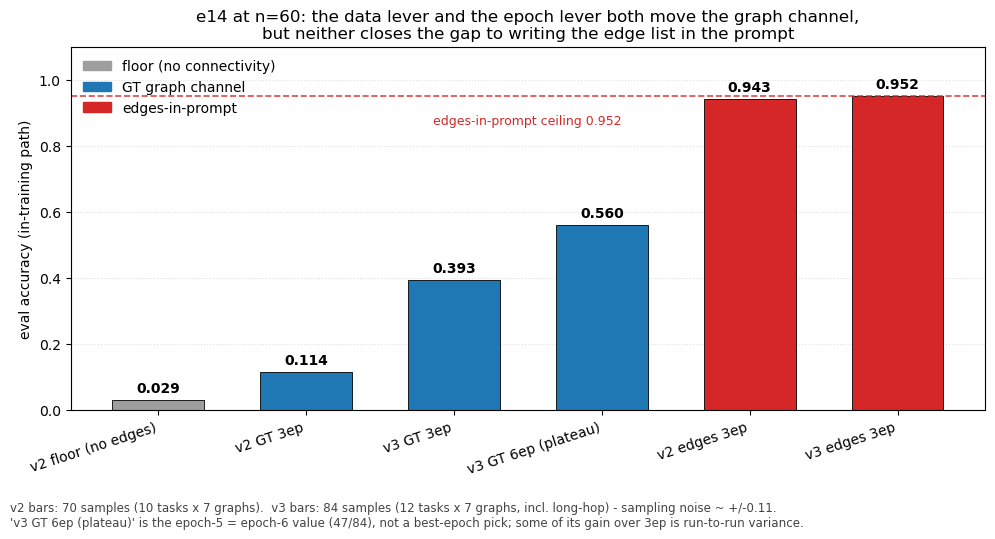

In [2]:
# n60 story only, worst -> best. Values are the "final acc" column above (in-training eval path).
PLOT_ROWS = [
    ("v2 floor (no edges)", 0.029, "floor"),
    ("v2 GT 3ep",           0.114, "GT"),
    ("v3 GT 3ep",           0.393, "GT"),
    ("v3 GT 6ep (plateau)", 0.560, "GT"),
    ("v2 edges 3ep",        0.943, "edges"),
    ("v3 edges 3ep",        0.952, "edges"),
]
COLORS = {"floor": "#9e9e9e", "GT": "#1f77b4", "edges": "#d62728"}
EDGES_CEILING = 0.952

labels = [r[0] for r in PLOT_ROWS]
values = [r[1] for r in PLOT_ROWS]
colors = [COLORS[r[2]] for r in PLOT_ROWS]

fig, ax = plt.subplots(figsize=(10, 5.4))
bars = ax.bar(labels, values, color=colors, width=0.62, edgecolor="black", linewidth=0.6)

ax.axhline(EDGES_CEILING, color="#d62728", linestyle="--", linewidth=1.2, alpha=0.85)
ax.text(2.5, EDGES_CEILING - 0.055, f"edges-in-prompt ceiling {EDGES_CEILING:.3f}",
        ha="center", va="top", fontsize=9, color="#d62728")

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, 1.10)
ax.set_ylabel("eval accuracy (in-training path)")
ax.set_title("e14 at n=60: the data lever and the epoch lever both move the graph channel,\n"
             "but neither closes the gap to writing the edge list in the prompt")
ax.tick_params(axis="x", labelrotation=18)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.set_axisbelow(True)

handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[k]) for k in ["floor", "GT", "edges"]]
ax.legend(handles, ["floor (no connectivity)", "GT graph channel", "edges-in-prompt"],
          loc="upper left", frameon=False)

fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.text(0.01, 0.015,
         "v2 bars: 70 samples (10 tasks x 7 graphs).  v3 bars: 84 samples (12 tasks x 7 graphs, "
         "incl. long-hop) - sampling noise ~ +/-0.11.\n"
         "'v3 GT 6ep (plateau)' is the epoch-5 = epoch-6 value (47/84), not a best-epoch pick; some "
         "of its gain over 3ep is run-to-run variance.",
         fontsize=8.5, color="#444444", ha="left")
plt.show()

## Takeaways

1. **The graph channel is real but does not scale.** At n30 it is 4.5× the floor (0.700 vs 0.157);
   at n60 on v2 it collapses to 0.114 while the text-edges bracket only slips 0.986 → 0.943. Going
   n30 → n60 the channel loses ~84% of its accuracy, the text bracket ~4%. The tasks are not the
   bottleneck — the connectivity *representation* is.
2. **The data lever works.** Doubling the corpus and adding long-hop tasks lifted the GT arm
   0.114 → 0.393 on a *harder* eval set (3.4×) and 0.114 → 0.457 on the identical legacy-10 subset
   (4×). Crucially, the fixed-path train/test probe moved on both halves — train 0.429 → 0.631, test
   0.200 → 0.440, retention 47% → 70% — so the gain is genuine transfer, not memorization of a
   bigger training set.
3. **The epoch lever adds more, then stops.** GT was still climbing at the 3-epoch cutoff; six epochs
   plateau at ~0.560 (legacy-10 0.571), and the long-hop subset finally moves 1/14 → 7/14 — the
   channel does learn some multi-hop routing given enough passes. That is this arm's practical
   ceiling on the v3 corpus.
4. **The gap narrows but never closes.** GT vs edges: 8.2× (v2 n60) → ~2.4× (v3, 3 epochs) → ~1.7×
   (v3, 6 epochs). Even at plateau, 0.560 sits far below 0.952 — and 0.631 on the model's *own*
   training graphs is still a fitting deficit, not merely a generalization one. Both halves of the
   n60 collapse improve with data; neither is solved by it.
5. **Where to look next:** residual failures are local phantom edges (true distance 2–3) and
   sibling/suffix confusion, with wide per-graph spread on the training set (0.417–0.917). A
   failure-mode pass over the weakest graphs, and an ablation separating "2× graphs" from "long-hop
   tasks" (the accepted v3 confound), are the natural follow-ups.